In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

print("Environment hazır")

Environment hazır


In [2]:

DATA_PATH = "../data/adult.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.columns)

df.head()

(32561, 15)
Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
print(df.shape)
print(df.columns)

(32561, 15)
Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')


In [4]:
df = df.replace("?", np.nan)

df = df.apply(
    lambda col: col.str.strip() if col.dtype == "object" else col
)

print(df.isna().sum())
print(df["income"].value_counts())
print(df["sex"].value_counts())

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64
income
<=50K    24720
>50K      7841
Name: count, dtype: int64
sex
Male      21790
Female    10771
Name: count, dtype: int64


In [5]:
df = df.dropna()

df["income"] = df["income"].replace({
    "<=50K": 0,
    ">50K": 1
})

df["sex_binary"] = df["sex"].replace({
    "Female": 0,
    "Male": 1
})

print(df.shape)

print(df["income"].value_counts())

print(df["sex_binary"].value_counts())

(30162, 16)
income
0    22654
1     7508
Name: count, dtype: int64
sex_binary
1    20380
0     9782
Name: count, dtype: int64


C:\Users\aalac\AppData\Local\Temp\ipykernel_5476\3773541528.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["income"] = df["income"].replace({
C:\Users\aalac\AppData\Local\Temp\ipykernel_5476\3773541528.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sex_binary"] = df["sex"].replace({


In [6]:
print(df.shape)
print(df["income"].value_counts())
print(df["sex_binary"].value_counts())

(30162, 16)
income
0    22654
1     7508
Name: count, dtype: int64
sex_binary
1    20380
0     9782
Name: count, dtype: int64


In [7]:
y = df["income"]

A = df["sex_binary"]  # protected attribute

X = df.drop(columns=["income"])

X_encoded = pd.get_dummies(X, drop_first=True)

print(X_encoded.shape)

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X_encoded,
    y,
    A,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

(30162, 97)
Train: (24129, 97)
Test: (6033, 97)


In [8]:
print(X_encoded.shape)
print(X_train.shape)
print(X_test.shape)

(30162, 97)
(24129, 97)
(6033, 97)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report
)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("=== Logistic Regression Baseline ===")
print(f"Accuracy : {acc:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

=== Logistic Regression Baseline ===
Accuracy : 0.8462
F1-score : 0.6555
ROC-AUC  : 0.8871

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4531
           1       0.74      0.59      0.66      1502

    accuracy                           0.85      6033
   macro avg       0.81      0.76      0.78      6033
weighted avg       0.84      0.85      0.84      6033



c:\Users\aalac\OneDrive\Masaüstü\makine öğrenmesi\fairness_tradeoff_project\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

lr_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=3000,
        solver="lbfgs",
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("=== Logistic Regression Baseline with Scaling ===")
print(f"Accuracy : {acc:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

=== Logistic Regression Baseline with Scaling ===
Accuracy : 0.8548
F1-score : 0.6815
ROC-AUC  : 0.9132

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4531
           1       0.75      0.62      0.68      1502

    accuracy                           0.85      6033
   macro avg       0.82      0.78      0.79      6033
weighted avg       0.85      0.85      0.85      6033



In [11]:
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference
)

spd = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

di = demographic_parity_ratio(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

eod = equalized_odds_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

print("=== Fairness Metrics ===")
print(f"Statistical Parity Difference (SPD): {spd:.4f}")
print(f"Disparate Impact Ratio (DI): {di:.4f}")
print(f"Equalized Odds Difference (EOD): {eod:.4f}")

=== Fairness Metrics ===
Statistical Parity Difference (SPD): 0.1745
Disparate Impact Ratio (DI): 0.3355
Equalized Odds Difference (EOD): 0.0872


In [12]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

spd_dt = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred_dt,
    sensitive_features=A_test
)

di_dt = demographic_parity_ratio(
    y_true=y_test,
    y_pred=y_pred_dt,
    sensitive_features=A_test
)

eod_dt = equalized_odds_difference(
    y_true=y_test,
    y_pred=y_pred_dt,
    sensitive_features=A_test
)

print("=== Decision Tree Baseline ===")

print(f"Accuracy : {acc_dt:.4f}")
print(f"F1-score : {f1_dt:.4f}")
print(f"ROC-AUC  : {auc_dt:.4f}")

print("\n=== Fairness Metrics ===")

print(f"SPD : {spd_dt:.4f}")
print(f"DI  : {di_dt:.4f}")
print(f"EOD : {eod_dt:.4f}")

=== Decision Tree Baseline ===
Accuracy : 0.8521
F1-score : 0.6518
ROC-AUC  : 0.8872

=== Fairness Metrics ===
SPD : 0.1501
DI  : 0.3291
EOD : 0.0656


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

spd_rf = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred_rf,
    sensitive_features=A_test
)

di_rf = demographic_parity_ratio(
    y_true=y_test,
    y_pred=y_pred_rf,
    sensitive_features=A_test
)

eod_rf = equalized_odds_difference(
    y_true=y_test,
    y_pred=y_pred_rf,
    sensitive_features=A_test
)

print("=== Random Forest Baseline ===")

print(f"Accuracy : {acc_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"ROC-AUC  : {auc_rf:.4f}")

print("\n=== Fairness Metrics ===")

print(f"SPD : {spd_rf:.4f}")
print(f"DI  : {di_rf:.4f}")
print(f"EOD : {eod_rf:.4f}")

=== Random Forest Baseline ===
Accuracy : 0.8586
F1-score : 0.6648
ROC-AUC  : 0.9181

=== Fairness Metrics ===
SPD : 0.1604
DI  : 0.2844
EOD : 0.1112


In [14]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

spd_xgb = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred_xgb,
    sensitive_features=A_test
)

di_xgb = demographic_parity_ratio(
    y_true=y_test,
    y_pred=y_pred_xgb,
    sensitive_features=A_test
)

eod_xgb = equalized_odds_difference(
    y_true=y_test,
    y_pred=y_pred_xgb,
    sensitive_features=A_test
)

print("=== XGBoost Baseline ===")

print(f"Accuracy : {acc_xgb:.4f}")
print(f"F1-score : {f1_xgb:.4f}")
print(f"ROC-AUC  : {auc_xgb:.4f}")

print("\n=== Fairness Metrics ===")

print(f"SPD : {spd_xgb:.4f}")
print(f"DI  : {di_xgb:.4f}")
print(f"EOD : {eod_xgb:.4f}")

=== XGBoost Baseline ===
Accuracy : 0.8734
F1-score : 0.7179
ROC-AUC  : 0.9336

=== Fairness Metrics ===
SPD : 0.1735
DI  : 0.3208
EOD : 0.1039


In [15]:
import pandas as pd

baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        acc,
        acc_dt,
        acc_rf,
        acc_xgb
    ],
    "F1": [
        f1,
        f1_dt,
        f1_rf,
        f1_xgb
    ],
    "ROC_AUC": [
        auc,
        auc_dt,
        auc_rf,
        auc_xgb
    ],
    "SPD": [
        spd,
        spd_dt,
        spd_rf,
        spd_xgb
    ],
    "DI": [
        di,
        di_dt,
        di_rf,
        di_xgb
    ],
    "EOD": [
        eod,
        eod_dt,
        eod_rf,
        eod_xgb
    ]
})

baseline_results

,Model,Accuracy,F1,ROC_AUC,SPD,DI,EOD
0,Logistic Regression,0.854799,0.681455,0.913242,0.174542,0.335510,0.087169
1,Decision Tree,0.852147,0.651835,0.887235,0.150071,0.329095,0.065625
2,Random Forest,0.858611,0.664833,0.918142,0.160408,0.284441,0.111219
3,XGBoost,0.873363,0.717873,0.933612,0.173453,0.320753,0.103941


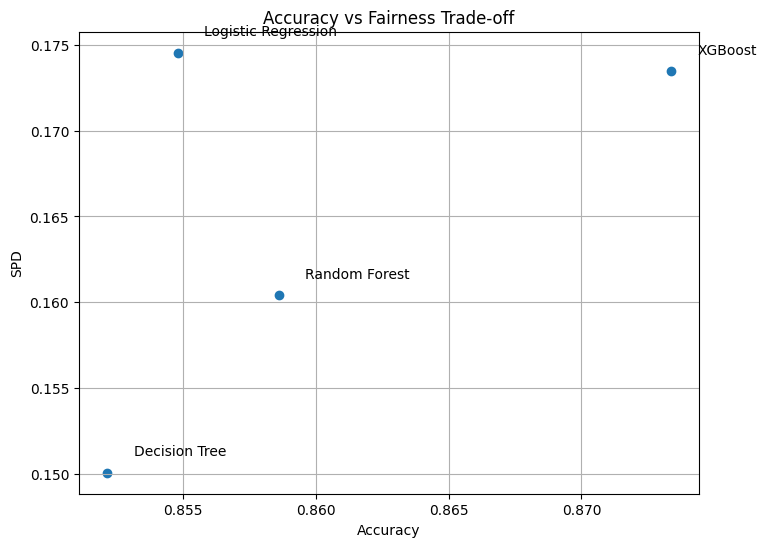

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    baseline_results["Accuracy"],
    baseline_results["SPD"]
)

for i, row in baseline_results.iterrows():
    plt.text(
        row["Accuracy"] + 0.001,
        row["SPD"] + 0.001,
        row["Model"]
    )

plt.xlabel("Accuracy")
plt.ylabel("SPD")
plt.title("Accuracy vs Fairness Trade-off")

plt.grid(True)

plt.show()

In [17]:
from aif360.datasets import BinaryLabelDataset

In [18]:
train_df = X_train.copy()

train_df["income"] = y_train.values
train_df["sex_binary"] = A_train.values

test_df = X_test.copy()

test_df["income"] = y_test.values
test_df["sex_binary"] = A_test.values

print(train_df.shape)
print(test_df.shape)

(24129, 98)
(6033, 98)


In [19]:
train_bld = BinaryLabelDataset(
    df=train_df,
    label_names=["income"],
    protected_attribute_names=["sex_binary"]
)

test_bld = BinaryLabelDataset(
    df=test_df,
    label_names=["income"],
    protected_attribute_names=["sex_binary"]
)

print(train_bld.features.shape)

(24129, 97)


In [20]:
from aif360.algorithms.preprocessing import Reweighing

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[inFairness]'


In [21]:
RW = Reweighing(
    unprivileged_groups=[{"sex_binary": 0}],
    privileged_groups=[{"sex_binary": 1}]
)

RW.fit(train_bld)

train_bld_transf = RW.transform(train_bld)

print("Reweighing tamam")

Reweighing tamam


In [22]:
sample_weights = train_bld_transf.instance_weights

lr_rw_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=3000,
        solver="lbfgs",
        random_state=42
    ))
])

lr_rw_model.fit(
    X_train,
    y_train,
    classifier__sample_weight=sample_weights
)

y_pred_lr_rw = lr_rw_model.predict(X_test)
y_prob_lr_rw = lr_rw_model.predict_proba(X_test)[:, 1]

acc_lr_rw = accuracy_score(y_test, y_pred_lr_rw)
f1_lr_rw = f1_score(y_test, y_pred_lr_rw)
auc_lr_rw = roc_auc_score(y_test, y_prob_lr_rw)

spd_lr_rw = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred_lr_rw,
    sensitive_features=A_test
)

di_lr_rw = demographic_parity_ratio(
    y_true=y_test,
    y_pred=y_pred_lr_rw,
    sensitive_features=A_test
)

eod_lr_rw = equalized_odds_difference(
    y_true=y_test,
    y_pred=y_pred_lr_rw,
    sensitive_features=A_test
)

print("=== Logistic Regression + Reweighing ===")
print(f"Accuracy : {acc_lr_rw:.4f}")
print(f"F1-score : {f1_lr_rw:.4f}")
print(f"ROC-AUC  : {auc_lr_rw:.4f}")

print("\n=== Fairness Metrics ===")
print(f"SPD : {spd_lr_rw:.4f}")
print(f"DI  : {di_lr_rw:.4f}")
print(f"EOD : {eod_lr_rw:.4f}")

=== Logistic Regression + Reweighing ===
Accuracy : 0.8475
F1-score : 0.6547
ROC-AUC  : 0.9054

=== Fairness Metrics ===
SPD : 0.0827
DI  : 0.6224
EOD : 0.1486


In [23]:
comparison_results = pd.DataFrame({
    "Model": [
        "LR Baseline",
        "LR + Reweighing"
    ],
    "Accuracy": [
        acc,
        acc_lr_rw
    ],
    "F1": [
        f1,
        f1_lr_rw
    ],
    "ROC_AUC": [
        auc,
        auc_lr_rw
    ],
    "SPD": [
        spd,
        spd_lr_rw
    ],
    "DI": [
        di,
        di_lr_rw
    ],
    "EOD": [
        eod,
        eod_lr_rw
    ]
})

comparison_results

,Model,Accuracy,F1,ROC_AUC,SPD,DI,EOD
0,LR Baseline,0.854799,0.681455,0.913242,0.174542,0.335510,0.087169
1,LR + Reweighing,0.847505,0.654655,0.905378,0.082715,0.622402,0.148613


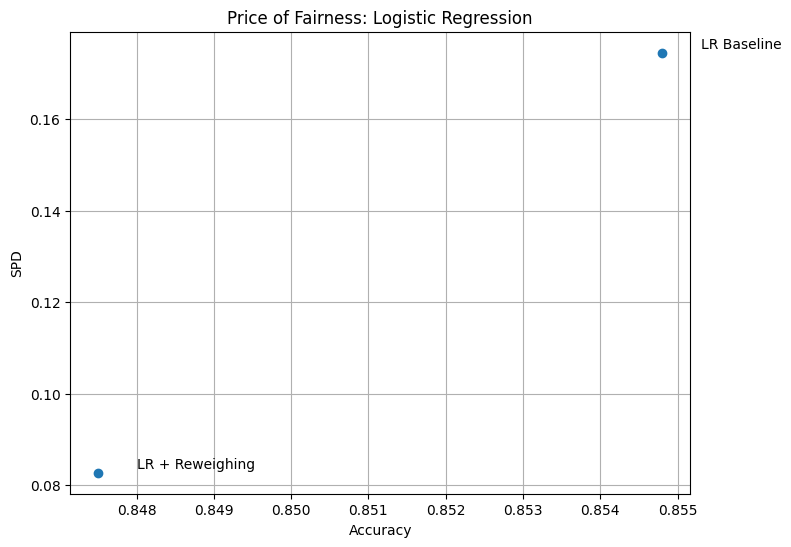

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    comparison_results["Accuracy"],
    comparison_results["SPD"]
)

for i, row in comparison_results.iterrows():
    plt.text(
        row["Accuracy"] + 0.0005,
        row["SPD"] + 0.001,
        row["Model"]
    )

plt.xlabel("Accuracy")
plt.ylabel("SPD")
plt.title("Price of Fairness: Logistic Regression")

plt.grid(True)

plt.show()

In [26]:
from fairlearn.reductions import (
    ExponentiatedGradient,
    DemographicParity
)

In [28]:
from fairlearn.reductions import (
    ExponentiatedGradient,
    DemographicParity
)

base_lr = LogisticRegression(
    max_iter=3000,
    solver="lbfgs"
)

mitigator = ExponentiatedGradient(
    estimator=base_lr,
    constraints=DemographicParity()
)

mitigator.fit(
    X_train,
    y_train,
    sensitive_features=A_train
)

y_pred_eg = mitigator.predict(X_test)

c:\Users\aalac\OneDrive\Masaüstü\makine öğrenmesi\fairness_tradeoff_project\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\aalac\OneDrive\Masaüstü\makine öğrenmesi\fairness_tradeoff_project\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might 

In [29]:
acc_eg = accuracy_score(y_test, y_pred_eg)
f1_eg = f1_score(y_test, y_pred_eg)

spd_eg = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred_eg,
    sensitive_features=A_test
)

di_eg = demographic_parity_ratio(
    y_true=y_test,
    y_pred=y_pred_eg,
    sensitive_features=A_test
)

eod_eg = equalized_odds_difference(
    y_true=y_test,
    y_pred=y_pred_eg,
    sensitive_features=A_test
)

print("=== Logistic Regression + Exponentiated Gradient ===")

print(f"Accuracy : {acc_eg:.4f}")
print(f"F1-score : {f1_eg:.4f}")

print("\n=== Fairness Metrics ===")

print(f"SPD : {spd_eg:.4f}")
print(f"DI  : {di_eg:.4f}")
print(f"EOD : {eod_eg:.4f}")

=== Logistic Regression + Exponentiated Gradient ===
Accuracy : 0.8326
F1-score : 0.6186

=== Fairness Metrics ===
SPD : 0.0072
DI  : 0.9626
EOD : 0.2957


In [30]:
lr_fairness_results = pd.DataFrame({
    "Model": [
        "LR Baseline",
        "LR + Reweighing",
        "LR + ExpGrad"
    ],
    "Accuracy": [
        acc,
        acc_lr_rw,
        acc_eg
    ],
    "F1": [
        f1,
        f1_lr_rw,
        f1_eg
    ],
    "SPD": [
        spd,
        spd_lr_rw,
        spd_eg
    ],
    "DI": [
        di,
        di_lr_rw,
        di_eg
    ],
    "EOD": [
        eod,
        eod_lr_rw,
        eod_eg
    ]
})

lr_fairness_results

,Model,Accuracy,F1,SPD,DI,EOD
0,LR Baseline,0.854799,0.681455,0.174542,0.335510,0.087169
1,LR + Reweighing,0.847505,0.654655,0.082715,0.622402,0.148613
2,LR + ExpGrad,0.832587,0.618580,0.007181,0.962645,0.295735


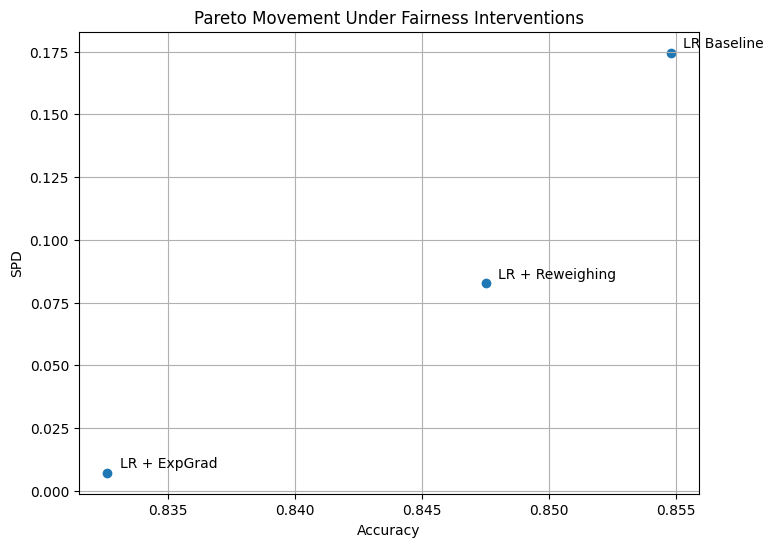

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    lr_fairness_results["Accuracy"],
    lr_fairness_results["SPD"]
)

for i, row in lr_fairness_results.iterrows():
    plt.text(
        row["Accuracy"] + 0.0005,
        row["SPD"] + 0.002,
        row["Model"]
    )

plt.xlabel("Accuracy")
plt.ylabel("SPD")
plt.title("Pareto Movement Under Fairness Interventions")

plt.grid(True)

plt.show()

In [ ]:
rf_rw_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_rw_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

y_pred_rf_rw = rf_rw_model.predict(X_test)
y_prob_rf_rw = rf_rw_model.predict_proba(X_test)[:, 1]

acc_rf_rw = accuracy_score(y_test, y_pred_rf_rw)
f1_rf_rw = f1_score(y_test, y_pred_rf_rw)
auc_rf_rw = roc_auc_score(y_test, y_prob_rf_rw)

spd_rf_rw = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred_rf_rw,
    sensitive_features=A_test
)

di_rf_rw = demographic_parity_ratio(
    y_true=y_test,
    y_pred=y_pred_rf_rw,
    sensitive_features=A_test
)

eod_rf_rw = equalized_odds_difference(
    y_true=y_test,
    y_pred=y_pred_rf_rw,
    sensitive_features=A_test
)

print("=== Random Forest + Reweighing ===")

print(f"Accuracy : {a.cc_rf_rw:.4f}")
print(f"F1-score : {f1_rf_rw:.4f}")
print(f"ROC-AUC  : {auc_rf_rw:.4f}")

print("\n=== Fairness Metrics ===")

print(f"SPD : {spd_rf_rw:.4f}")
print(f"DI  : {di_rf_rw:.4f}")
print(f"EOD : {eod_rf_rw:.4f}")

=== Random Forest + Reweighing ===
Accuracy : 0.8518
F1-score : 0.6455
ROC-AUC  : 0.9133

=== Fairness Metrics ===
SPD : 0.0649
DI  : 0.6582
EOD : 0.1939


In [33]:
all_results = pd.DataFrame({
    "Model": [
        "LR Baseline",
        "LR + Reweighing",
        "LR + ExpGrad",
        "RF Baseline",
        "RF + Reweighing"
    ],

    "Accuracy": [
        acc,
        acc_lr_rw,
        acc_eg,
        acc_rf,
        acc_rf_rw
    ],

    "F1": [
        f1,
        f1_lr_rw,
        f1_eg,
        f1_rf,
        f1_rf_rw
    ],

    "ROC_AUC": [
        auc,
        auc_lr_rw,
        np.nan,
        auc_rf,
        auc_rf_rw
    ],

    "SPD": [
        spd,
        spd_lr_rw,
        spd_eg,
        spd_rf,
        spd_rf_rw
    ],

    "DI": [
        di,
        di_lr_rw,
        di_eg,
        di_rf,
        di_rf_rw
    ],

    "EOD": [
        eod,
        eod_lr_rw,
        eod_eg,
        eod_rf,
        eod_rf_rw
    ]
})

all_results

,Model,Accuracy,F1,ROC_AUC,SPD,DI,EOD
0,LR Baseline,0.854799,0.681455,0.913242,0.174542,0.335510,0.087169
1,LR + Reweighing,0.847505,0.654655,0.905378,0.082715,0.622402,0.148613
2,LR + ExpGrad,0.832587,0.618580,NaN,0.007181,0.962645,0.295735
3,RF Baseline,0.858611,0.664833,0.918142,0.160408,0.284441,0.111219
4,RF + Reweighing,0.851815,0.645519,0.913302,0.064880,0.658195,0.193926


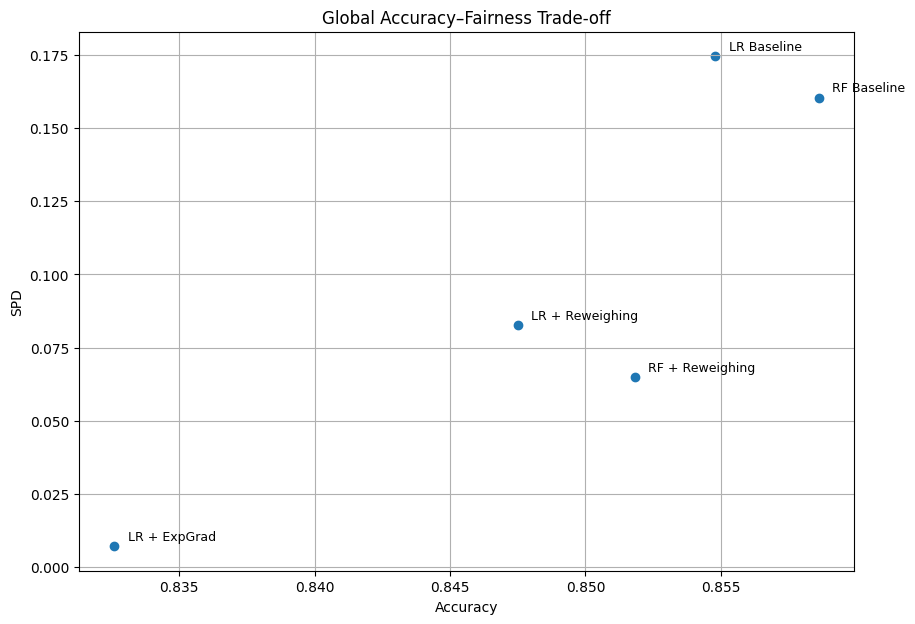

In [34]:
plt.figure(figsize=(10,7))

plt.scatter(
    all_results["Accuracy"],
    all_results["SPD"]
)

for i, row in all_results.iterrows():
    plt.text(
        row["Accuracy"] + 0.0005,
        row["SPD"] + 0.002,
        row["Model"],
        fontsize=9
    )

plt.xlabel("Accuracy")
plt.ylabel("SPD")
plt.title("Global Accuracy–Fairness Trade-off")

plt.grid(True)

plt.show()

In [35]:
xgb_rw_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_rw_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

y_pred_xgb_rw = xgb_rw_model.predict(X_test)
y_prob_xgb_rw = xgb_rw_model.predict_proba(X_test)[:, 1]

acc_xgb_rw = accuracy_score(y_test, y_pred_xgb_rw)
f1_xgb_rw = f1_score(y_test, y_pred_xgb_rw)
auc_xgb_rw = roc_auc_score(y_test, y_prob_xgb_rw)

spd_xgb_rw = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred_xgb_rw,
    sensitive_features=A_test
)

di_xgb_rw = demographic_parity_ratio(
    y_true=y_test,
    y_pred=y_pred_xgb_rw,
    sensitive_features=A_test
)

eod_xgb_rw = equalized_odds_difference(
    y_true=y_test,
    y_pred=y_pred_xgb_rw,
    sensitive_features=A_test
)

print("=== XGBoost + Reweighing ===")

print(f"Accuracy : {acc_xgb_rw:.4f}")
print(f"F1-score : {f1_xgb_rw:.4f}")
print(f"ROC-AUC  : {auc_xgb_rw:.4f}")

print("\n=== Fairness Metrics ===")

print(f"SPD : {spd_xgb_rw:.4f}")
print(f"DI  : {di_xgb_rw:.4f}")
print(f"EOD : {eod_xgb_rw:.4f}")

=== XGBoost + Reweighing ===
Accuracy : 0.8700
F1-score : 0.7057
ROC-AUC  : 0.9301

=== Fairness Metrics ===
SPD : 0.0850
DI  : 0.6133
EOD : 0.1748


In [36]:
final_results = pd.DataFrame({

    "Model": [
        "LR Baseline",
        "LR + Reweighing",
        "LR + ExpGrad",
        "RF Baseline",
        "RF + Reweighing",
        "XGB Baseline",
        "XGB + Reweighing"
    ],

    "Accuracy": [
        acc,
        acc_lr_rw,
        acc_eg,
        acc_rf,
        acc_rf_rw,
        acc_xgb,
        acc_xgb_rw
    ],

    "F1": [
        f1,
        f1_lr_rw,
        f1_eg,
        f1_rf,
        f1_rf_rw,
        f1_xgb,
        f1_xgb_rw
    ],

    "ROC_AUC": [
        auc,
        auc_lr_rw,
        np.nan,
        auc_rf,
        auc_rf_rw,
        auc_xgb,
        auc_xgb_rw
    ],

    "SPD": [
        spd,
        spd_lr_rw,
        spd_eg,
        spd_rf,
        spd_rf_rw,
        spd_xgb,
        spd_xgb_rw
    ],

    "DI": [
        di,
        di_lr_rw,
        di_eg,
        di_rf,
        di_rf_rw,
        di_xgb,
        di_xgb_rw
    ],

    "EOD": [
        eod,
        eod_lr_rw,
        eod_eg,
        eod_rf,
        eod_rf_rw,
        eod_xgb,
        eod_xgb_rw
    ]
})

final_results

,Model,Accuracy,F1,ROC_AUC,SPD,DI,EOD
0,LR Baseline,0.854799,0.681455,0.913242,0.174542,0.335510,0.087169
1,LR + Reweighing,0.847505,0.654655,0.905378,0.082715,0.622402,0.148613
2,LR + ExpGrad,0.832587,0.618580,NaN,0.007181,0.962645,0.295735
3,RF Baseline,0.858611,0.664833,0.918142,0.160408,0.284441,0.111219
4,RF + Reweighing,0.851815,0.645519,0.913302,0.064880,0.658195,0.193926
5,XGB Baseline,0.873363,0.717873,0.933612,0.173453,0.320753,0.103941
6,XGB + Reweighing,0.870048,0.705706,0.930116,0.085001,0.613256,0.174775


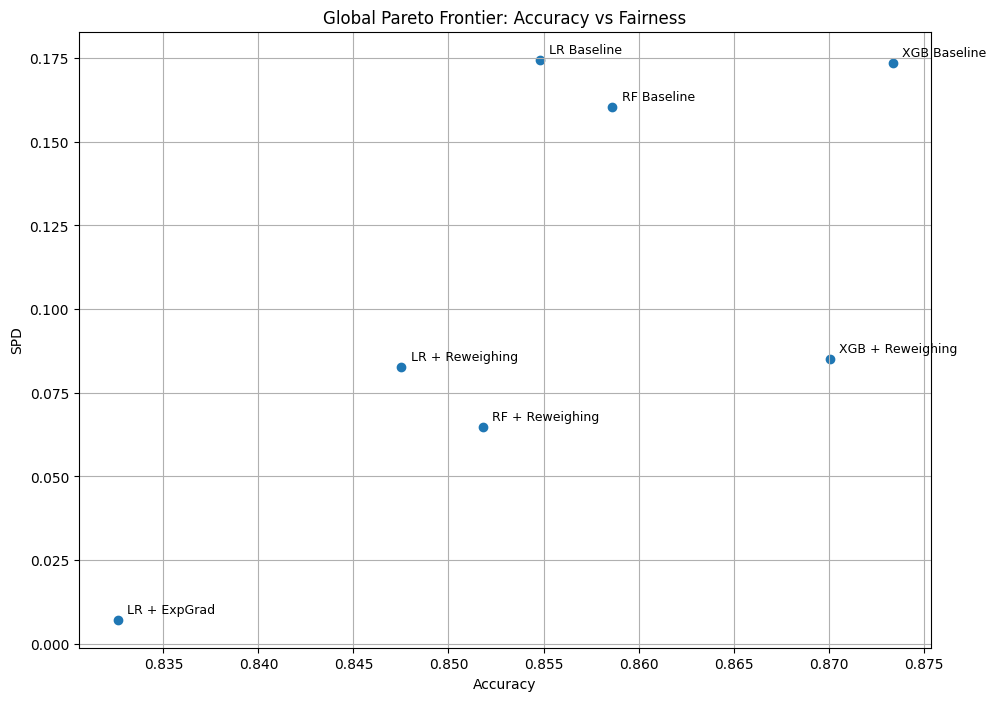

In [37]:
plt.figure(figsize=(11,8))

plt.scatter(
    final_results["Accuracy"],
    final_results["SPD"]
)

for i, row in final_results.iterrows():
    plt.text(
        row["Accuracy"] + 0.0005,
        row["SPD"] + 0.002,
        row["Model"],
        fontsize=9
    )

plt.xlabel("Accuracy")
plt.ylabel("SPD")
plt.title("Global Pareto Frontier: Accuracy vs Fairness")

plt.grid(True)

plt.show()

In [38]:
final_results.to_csv(
    "../results/final_results.csv",
    index=False
)

print("Results saved.")

Results saved.


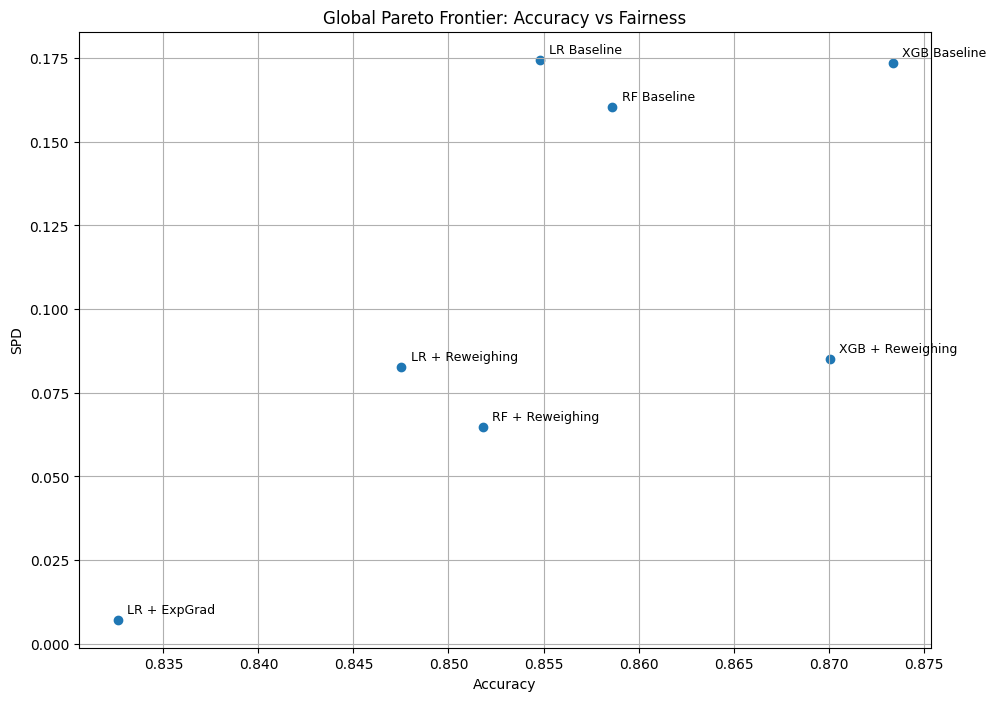

In [39]:
plt.figure(figsize=(11,8))

plt.scatter(
    final_results["Accuracy"],
    final_results["SPD"]
)

for i, row in final_results.iterrows():
    plt.text(
        row["Accuracy"] + 0.0005,
        row["SPD"] + 0.002,
        row["Model"],
        fontsize=9
    )

plt.xlabel("Accuracy")
plt.ylabel("SPD")
plt.title("Global Pareto Frontier: Accuracy vs Fairness")

plt.grid(True)

plt.savefig(
    "../results/global_pareto_frontier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()